# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models? **We use generalized linear models/latent variable models/activation functions because many real outcomes are not well modeled by a straight line, so these functionas let us keep a linear combination of features, but transform it so the output matches the problem, like probabilities staying between 0 and 1. This makes them more flexible and more appropriate to use than plain linear regression at times.**
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models. **Cross-entropy is effective because logistic regression predicts probabilities, and cross-entropy measures how close those probabilities are to the true labels. It also penalizes confident wrong predictions strongly (helping fitting the model).**
3. True or false, and explain: Logistic regression is a linear model. **True (in the log-odds).**
4. True or false, and explain: Logistic regression cannot be used for classification. **False, as LR is commonly used for classification.**
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable? **No, instead it represents a change in the log-odds (the effect on the actual predicted probability depends on where you already are on the logistic curve).**
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model. **False, if the real relationship is more complex, you may need interaction terms, polynomial terms, transformations, etc.**
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead. **False. You should not always use LR, it's better in binary outcomes, but if the response is continuous then OLS is better.**

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout. **No missing values were present.**


In [4]:
import pandas as pd
df = pd.read_csv("data/data.csv", sep=";") # saw in the dataset that they were separated by semicolons.
cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target",
]
data = df[cols].copy()
# there were no missing values, so no imputation or row deletion required.
print(data.isna().sum())

# binary target
data["dropout"] = (data["Target"] == "Dropout").astype(int)

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64



2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk? **Debtor and Age at enrollment seem to predict higher dropout probability, whereas Tuition fees up to date and Scholarship holder seem to predict a lower dropout probability. Yes, being up to date on tuition reduces dropout risk since its coefficient is large and negative.**


In [5]:
from sklearn.linear_model import LogisticRegression
X = data[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
y = data["dropout"]
logit = LogisticRegression(max_iter=5000)
logit.fit(X, y)
print(pd.Series(logit.coef_[0], index=X.columns))
print("Intercept:", logit.intercept_[0])

Debtor                     0.530625
Tuition fees up to date   -2.556542
Scholarship holder        -1.227442
Age at enrollment          0.049925
dtype: float64
Intercept: 0.48569265741188955



3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout? **The average is printed below, sitting at around -0.516. Being up to date on tuition seems to reduce dropout probability the most from ages 20-24.**


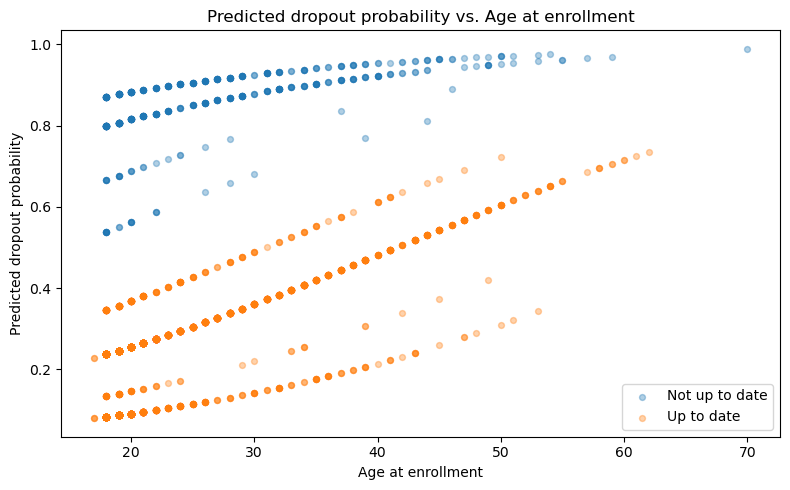

Average tuition effect: -0.5161819741213389
Age at enrollment
22   -0.537499
23   -0.535802
21   -0.535541
20   -0.532669
24   -0.531446
19   -0.529255
25   -0.527728
26   -0.527287
18   -0.525951
27   -0.524518
Name: tuition_effect, dtype: float64


In [6]:
import matplotlib.pyplot as plt
data["logit_prob"] = logit.predict_proba(X)[:, 1]
X_up = X.copy()
X_up["Tuition fees up to date"] = 1
X_not = X.copy()
X_not["Tuition fees up to date"] = 0
data["prob_if_up_to_date"] = logit.predict_proba(X_up)[:, 1]
data["prob_if_not_up_to_date"] = logit.predict_proba(X_not)[:, 1]
data["tuition_effect"] = data["prob_if_up_to_date"] - data["prob_if_not_up_to_date"]

plt.figure(figsize=(8, 5))
for tuition_value, label in [(0, "Not up to date"), (1, "Up to date")]:
    subset = data[data["Tuition fees up to date"] == tuition_value]
    plt.scatter(
        subset["Age at enrollment"],
        subset["logit_prob"],
        alpha=0.35,
        s=18,
        label=label
    )
plt.xlabel("Age at enrollment")
plt.ylabel("Predicted dropout probability")
plt.title("Predicted dropout probability vs. Age at enrollment")
plt.legend()
plt.tight_layout()
plt.show()

print("Average tuition effect:", data["tuition_effect"].mean())
print(data.groupby("Age at enrollment")["tuition_effect"].mean().sort_values().head(10))


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy? **76.12%**


In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score
logit_pred = logit.predict(X)
cm = confusion_matrix(y, logit_pred)
acc = accuracy_score(y, logit_pred)
print(cm)
print(acc)

[[2841  162]
 [ 891  530]]
0.7619801084990958



5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance. **Linear model has a very similar performance with an accuracy of around 76.3%. Even though it's slightly above logisitic regression's performance, logistic regression is still preferred, since it gives values from 0-1, but linear can give more than that.**


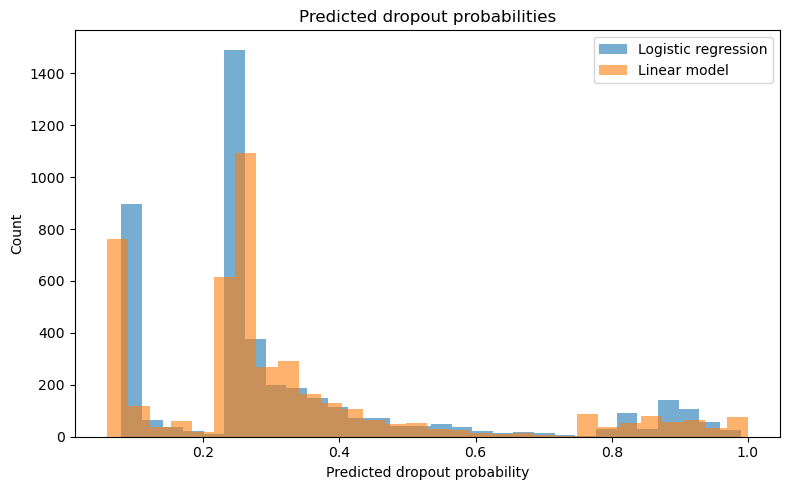

linear accuracy: 0.7633363471971067
linear confusion matrix:
 [[2870  133]
 [ 914  507]]
raw linear prediction range: 0.05832035022574156 1.334953570675864


In [9]:
from sklearn.linear_model import LinearRegression
import numpy as np
lin = LinearRegression()
lin.fit(X, y)
data["lin_prob_raw"] = lin.predict(X)
data["lin_prob"] = np.clip(data["lin_prob_raw"], 0, 1)

plt.figure(figsize=(8, 5))
plt.hist(data["logit_prob"], bins=30, alpha=0.6, label="Logistic regression")
plt.hist(data["lin_prob"], bins=30, alpha=0.6, label="Linear model")
plt.xlabel("Predicted dropout probability")
plt.ylabel("Count")
plt.title("Predicted dropout probabilities")
plt.legend()
plt.tight_layout()
plt.show()
lin_pred = (data["lin_prob"] >= 0.5).astype(int)

print("linear accuracy:", accuracy_score(y, lin_pred))
print("linear confusion matrix:\n", confusion_matrix(y, lin_pred))
print("raw linear prediction range:", data["lin_prob_raw"].min(), data["lin_prob_raw"].max())


5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?
**The types of students that are most at-risk of dropping out are debtors, those not up to date on tuition, older at enrollment, and not scholarship holders. To me, it seems like the kinds of interventions that would help them are financial related ones, specifically through things like financial aid and advising.**


6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? **It has an accuracy of about 70.5%. Its hard predictions only classify observations like `Dropout` and `Graduate`. It does not hard classify any student labeled as `Enrolled`. The predicted probabilities from `predict_proba` include nonzero probabilities for `Enrolled` though, so hard classification does not predict every class, but predicted probabilities do assign probability to every class.**


In [10]:
X_multi = data[["Debtor", "Tuition fees up to date", "Curricular units 1st sem (approved)"]]
y_multi = data["Target"]
multi = LogisticRegression(max_iter=5000)
multi.fit(X_multi, y_multi)
multi_pred = multi.predict(X_multi)
multi_probs = multi.predict_proba(X_multi)

print("classes:", multi.classes_)
print(confusion_matrix(y_multi, multi_pred, labels=multi.classes_))
print("accuracy:", accuracy_score(y_multi, multi_pred))
print("unique hard predictions:", pd.unique(multi_pred))
probs_df = pd.DataFrame(multi_probs, columns=multi.classes_)
print(probs_df.head())

classes: ['Dropout' 'Enrolled' 'Graduate']
[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
accuracy: 0.7045660036166366
unique hard predictions: ['Dropout' 'Graduate']
    Dropout  Enrolled  Graduate
0  0.680547  0.210464  0.108989
1  0.695414  0.146043  0.158543
2  0.952988  0.041199  0.005813
3  0.117808  0.176983  0.705209
4  0.184227  0.212669  0.603104


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values. **I handled the missing Drug values in parts 2-5 by just dropping them, and missing Stage in part 6.**


In [12]:
import pandas as pd
df = pd.read_csv("data/cirrhosis.csv")
cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
data = df[cols].copy()
print(data.isna().sum())

Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64



2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema? **Since `Drug_Placebo` is positive, the model suggests placebo has a slightly higher survival probability than D-penicillamine, so the drug does not appear to improve survival probability in this sample. Bilirubin has a negative coefficient, so higher bilirubin predicts lower survival. S Edema is associated with lower survival, and Y Edema is associated with an even lower survival rate, showing that it gets worse as Edema severity increases.**


In [16]:
from sklearn.linear_model import LogisticRegression
data = df[["Bilirubin", "Edema", "Drug", "Status"]].dropna().copy()
data["survive"] = data["Status"].isin(["C", "CL"]).astype(int) #1 is alive, 0 is dead
X = pd.get_dummies(data[["Edema", "Drug", "Bilirubin"]], drop_first=True)
y = data["survive"]
logit = LogisticRegression(max_iter=5000)
logit.fit(X, y)
print(pd.Series(logit.coef_[0], index=X.columns))

Bilirubin      -0.351424
Edema_S        -0.450677
Edema_Y        -1.611049
Drug_Placebo    0.231225
dtype: float64



3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? **On average, by how much do patients who take the drug increase their probability of survival? In this model, no value range of Bilirubin seems to make the drug seem to increase patient survival rate. On average, it's actually around -0.042. I will say though that at very high Bilirubin levels the patient survival rate becomes close to 0.**


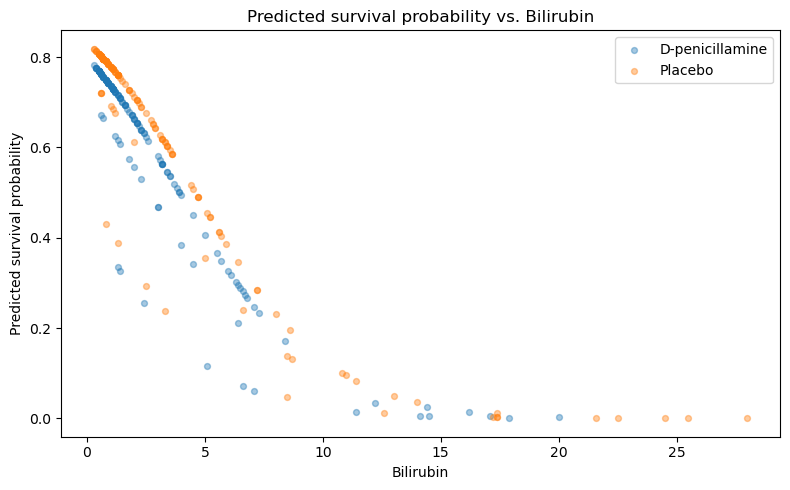

Average drug effect: -0.04242663943164009
Bilirubin
(-inf, 1.0]   -0.040532
(1.0, 2.0]    -0.046648
(2.0, 5.0]    -0.054263
(5.0, 10.0]   -0.043324
(10.0, inf]   -0.004328
Name: drug_effect, dtype: float64


/var/folders/6f/dqpwlsc14sxdccwn8z1vnq7m0000gn/T/ipykernel_23852/3250311787.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby(pd.cut(data["Bilirubin"], bins=[-float("inf"),1,2,5,10,float("inf")]))["drug_effect"].mean())


In [17]:
data = df[["Bilirubin", "Edema", "Drug", "Status"]].dropna().copy()
data["survive"] = data["Status"].isin(["C", "CL"]).astype(int)
X = pd.get_dummies(data[["Edema", "Drug", "Bilirubin"]], drop_first=True)
y = data["survive"]
logit = LogisticRegression(max_iter=5000)
logit.fit(X, y)
data["survival_prob"] = logit.predict_proba(X)[:, 1]
X_dpen = X.copy()
X_dpen["Drug_Placebo"] = 0
X_placebo = X.copy()
X_placebo["Drug_Placebo"] = 1
data["prob_dpen"] = logit.predict_proba(X_dpen)[:, 1]
data["prob_placebo"] = logit.predict_proba(X_placebo)[:, 1]
data["drug_effect"] = data["prob_dpen"] - data["prob_placebo"]

plt.figure(figsize=(8, 5))
for drug_name in ["D-penicillamine", "Placebo"]:
    subset = data[data["Drug"] == drug_name]
    plt.scatter(
        subset["Bilirubin"],
        subset["survival_prob"],
        alpha=0.4,
        s=18,
        label=drug_name
    )
plt.xlabel("Bilirubin")
plt.ylabel("Predicted survival probability")
plt.title("Predicted survival probability vs. Bilirubin")
plt.legend()
plt.tight_layout()
plt.show()
print("Average drug effect:", data["drug_effect"].mean())
print(data.groupby(pd.cut(data["Bilirubin"], bins=[-float("inf"),1,2,5,10,float("inf")]))["drug_effect"].mean())


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy? **73.7%**


In [18]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
data = df[["Bilirubin", "Edema", "Drug", "Status"]].dropna().copy()
data["survive"] = data["Status"].isin(["C", "CL"]).astype(int)
X = pd.get_dummies(data[["Edema", "Drug", "Bilirubin"]], drop_first=True)
y = data["survive"]
logit = LogisticRegression(max_iter=5000)
logit.fit(X, y)
pred = logit.predict(X)
print(confusion_matrix(y, pred))
print("accuracy:", accuracy_score(y, pred))

[[ 59  66]
 [ 16 171]]
accuracy: 0.7371794871794872



5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance. **The logistic model performed slightly better here (accuracies are printed below)**


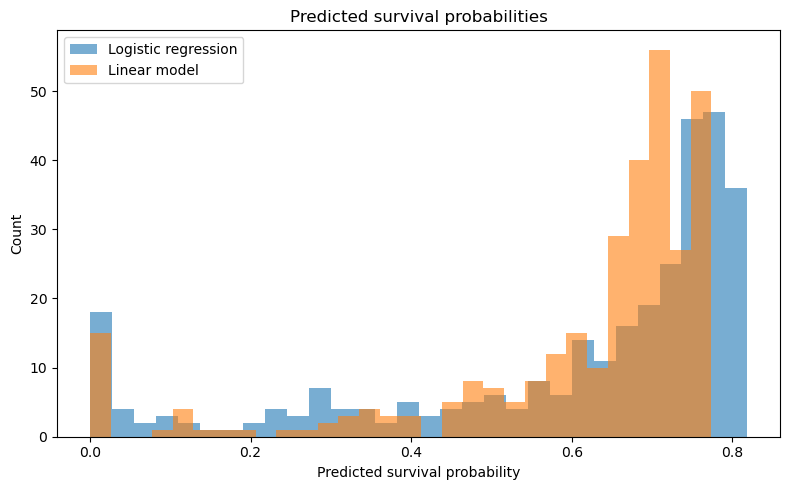

logistic accuracy: 0.7371794871794872
linear accuracy: 0.7211538461538461


In [19]:
data = df[["Bilirubin", "Edema", "Drug", "Status"]].dropna().copy()
data["survive"] = data["Status"].isin(["C", "CL"]).astype(int)
X = pd.get_dummies(data[["Edema", "Drug", "Bilirubin"]], drop_first=True)
y = data["survive"]
#logistic
logit = LogisticRegression(max_iter=5000)
logit.fit(X, y)
data["logit_prob"] = logit.predict_proba(X)[:, 1]
logit_pred = logit.predict(X)
#linear
lin = LinearRegression()
lin.fit(X, y)
data["lin_prob_raw"] = lin.predict(X)
data["lin_prob"] = np.clip(data["lin_prob_raw"], 0, 1)
lin_pred = (data["lin_prob"] >= 0.5).astype(int)

plt.figure(figsize=(8, 5))
plt.hist(data["logit_prob"], bins=30, alpha=0.6, label="Logistic regression")
plt.hist(data["lin_prob"], bins=30, alpha=0.6, label="Linear model")
plt.xlabel("Predicted survival probability")
plt.ylabel("Count")
plt.title("Predicted survival probabilities")
plt.legend()
plt.tight_layout()
plt.show()
print("logistic accuracy:", accuracy_score(y, logit_pred))
print("linear accuracy:", accuracy_score(y, lin_pred))


6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?  **Upon seeing the results, I think that the model performs pretty poorly given that accuracy. The hard classifier does not predict every class, as it never predicts stage 1 or 2. But, the predicted probabilities do assign probability to every class. This ultimately suggests that Edema and Bilirubin alone are not enough to separate all four stages very well.**

In [20]:

data = df[["Stage", "Edema", "Bilirubin"]].dropna().copy()
data["Stage"] = data["Stage"].astype(int)
X = pd.get_dummies(data[["Edema", "Bilirubin"]], drop_first=True)
y = data["Stage"]
model = LogisticRegression(max_iter=5000)
model.fit(X, y)
pred = model.predict(X)
probs = pd.DataFrame(model.predict_proba(X), columns=model.classes_)

print("classes:", model.classes_)
print(confusion_matrix(y, pred, labels=model.classes_))
print("accuracy:", accuracy_score(y, pred))
print("unique hard predictions:", pd.Series(pred).value_counts().sort_index())
print(probs.head())

classes: [1 2 3 4]
[[  0   0  20   1]
 [  0   0  82  10]
 [  0   0 130  25]
 [  0   0  93  51]]
accuracy: 0.4393203883495146
unique hard predictions: 3    325
4     87
Name: count, dtype: int64
          1         2         3         4
0  0.000469  0.051111  0.137332  0.811088
1  0.068675  0.255046  0.397581  0.278698
2  0.039844  0.139560  0.340088  0.480508
3  0.035217  0.137518  0.338843  0.488422
4  0.035049  0.243195  0.404019  0.317738


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

Given the linear model:

$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$

the derivative of the prediction with respect to the $k$-th feature is:

$$
\frac{\partial \hat{y}}{\partial x_k} = b_k
$$

So for a 1-unit change in $x_k$ the prediction changes by exactly:

$$
b_k
$$

units.

We can interpret this as if $b_k > 0$, increasing $x_k$ increases the prediction, and if $b_k < 0$, increasing $x_k$ decreases the prediction.


2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

Starting from given logistic model:

$$
\hat{p} = \frac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$

let

$$
L = b \cdot x
$$

Then

$$
\hat{p} = \frac{e^L}{1+e^L}
$$

Using the hint above

$$
\frac{\partial \hat{p}}{\partial L} = \hat{p}(1-\hat{p})
$$

and since

$$
\frac{\partial L}{\partial x_k} = b_k
$$

the chain rule gives

$$
\frac{\partial \hat{p}}{\partial x_k}
=
\frac{\partial \hat{p}}{\partial L}\frac{\partial L}{\partial x_k}
=
\hat{p}(1-\hat{p})b_k
$$

So the derivative is:

$$
\frac{\partial \hat{p}}{\partial x_k} = \hat{p}(1-\hat{p})b_k
$$

And a 1-unit increase in $x_k$ changes the predicted probability by approximately:

$$
\hat{p}(1-\hat{p})b_k
$$

Unlike the linear model, this effect depends on the current value of $\hat{p}$, so it changes as $x$ changes.

The quantity $\hat{p}(1-\hat{p})$ is largest when

$$
\hat{p} = 0.5
$$

and then

$$
\hat{p}(1-\hat{p}) = 0.25
$$

So near $\hat{p} = 0.5$,

$$
\frac{\partial \hat{p}}{\partial x_k} \approx \frac{b_k}{4}
$$

AKA the coefficient divided by 4 is a good rough estimate of the change in predicted probability when $\hat{p}$ is near 0.5.



3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

Starting from

$$
\log\left(\frac{\hat{p}}{1-\hat{p}}\right) = b \cdot x
$$

differentiate both sides with respect to $x_k$:

$$
\frac{\partial}{\partial x_k}\log\left(\frac{\hat{p}}{1-\hat{p}}\right)
=
\frac{\partial}{\partial x_k}(b \cdot x)
=
b_k
$$

So a 1-unit increase in $x_k$ changes the log-odds by exactly

$$
b_k
$$